<a href="https://colab.research.google.com/github/Jmontoyaor/SignalsandSystems-/blob/main/PARCIAL_1_SE%C3%91ALES_Y_SISTEMAS_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PARCIAL I -  SEÑALES Y SISTEMAS  
- JUAN FERNANDO MONTOYA ORTIZ
- DI 1056121321

#EJERCICIO 1

Se tiene un microprocesador de **5 bits** con entrada análoga de \(-3.3\) a \(5\) [V]. Diseñe el sistema de acondicionamiento y digitalización para la señal:

$$
x(t) = 20\sin(7t - \frac{\pi}{2}) - 3\cos(5t) + 2\cos(10t)
$$

Presente las **simulaciones y gráficas** de los procedimientos más representativos en un cuaderno de Python, incluyendo al menos **dos períodos** de la señal estudiada.


In [ ]:
from scipy.spatial.distance import cdist

import numpy as np
import matplotlib.pyplot as plt

# Funcion del Cálculo de pendiente y del offset (cero)
def my_ceropen(x, ymin=-5, ymax=5):
    xmax = max(x)    # valor min después de cero y pendiente
    xmin = min(x)
    m = (ymax - ymin)/(xmax - xmin)
    c = ymin - m*xmin
    yv = m*x + c
    return yv


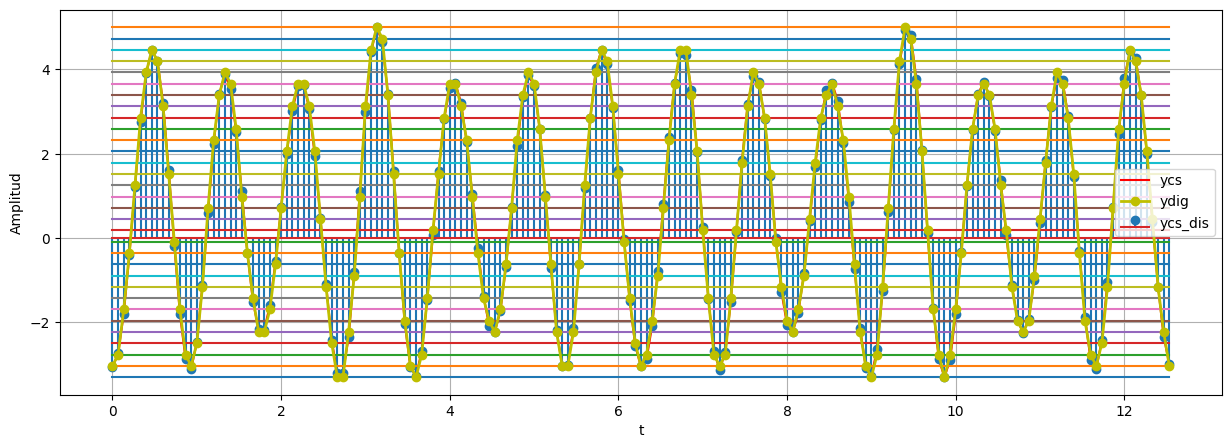

In [ ]:

import numpy as np



# funcion de conversor( discretizador + cuantizador)

def conversor_AD(signal, rmin, rmax, nbits):
    '''
    Simula un conversor A/D:
    - signal: vector de señal
    - rmin, rmax: rango deseado de cuantización
    - nbits: resolución en bits del ADC
    '''
    # Acondicionamiento
    sig_c = my_ceropen(signal, ymin=rmin, ymax=rmax)

    # Crear niveles de cuantización
    ve = np.linspace(rmin, rmax, 2**nbits)

    # Cuantización usando cdist y argmin

    d = cdist(sig_c.reshape(-1,1), ve.reshape(-1,1))  #Calcula la distancia entre dos vectores, preparandolo para la cuantizacon.

    ind = np.argmin(d, axis=1)  #Encuentra el nivel más cercano ( cuantización)

    yq = ve[ind]


    plt.figure(figsize=(15, 5)) # Tamaño de la grafica
#Graficar señales
    plt.plot(tv, sig_c, c='r', label='ycs')  # Continua
    plt.stem(tv, sig_c, label='ycs_dis')   # grafica señales discretas  con líneas verticales desde el eje X (palitos).

  #estados de cuantización

    for v in ve:
      plt.plot(tv,v*np.ones(len(tv)))

    # graficar señal Digital (discreta + cuantizada)

    plt.plot(tv,yq,c='y',marker='o',label='ydig', linewidth=2)


    plt.legend()
    plt.grid()
    plt.xlabel('t')                      #etiquetas
    plt.ylabel('Amplitud')               #etiquetas
    plt.show()


    return sig_c, yq, ve



# Parámetros
A = -20                     # Amplitud de ambas señales
B=-3
C= 2


T1 = (2 * np.pi) /7           # Periodo de la primera señal
T2 = (2 * np.pi)/5            # Periodo de la segunda señal
T3= (2 * np.pi)/10            # Periodo de la segunda señal
T = 2*np.pi

w1 = 2 * np.pi / T1       # Frecuencia angular de la primera señal
w2 = 2 * np.pi / T2       # Frecuencia angular de la segunda señal
w3 = 2 * np.pi / T3       # Frecuencia angular de la tercera señal


Fs = 15  # Frecuencia de muestreo (Hz)
Ts = 1 / Fs               # Periodo de muestreo

ti = 0
tf = 2*T


tv = np.arange(ti, tf, Ts)  # Vector de tiempo

# Señal compuesta
y = A * np.cos(w1 * tv) + B * np.cos(w2 * tv)+ C*np.cos(w3*tv)


ycs, yq, ve = conversor_AD(y, -3.3, 5, 5)  # llamamos funcion_AD,  Acondicionamiento,Señal cuantizada, niveles de cuantización



#EJERCICIO 2
¿Cuál es la señal obtenida en **tiempo discreto** al utilizar un conversor análogo-digital con frecuencia de muestreo de **5 kHz**, aplicado a la señal:

$$
x(t) = 3\cos(1000\pi t) + 5\sin(2000\pi t) + 10\cos(11000\pi t)?
$$

Realizar la **simulación del proceso de discretización**. En caso de que la discretización no sea apropiada, diseñe e implemente un **conversor adecuado para la señal estudiada**.


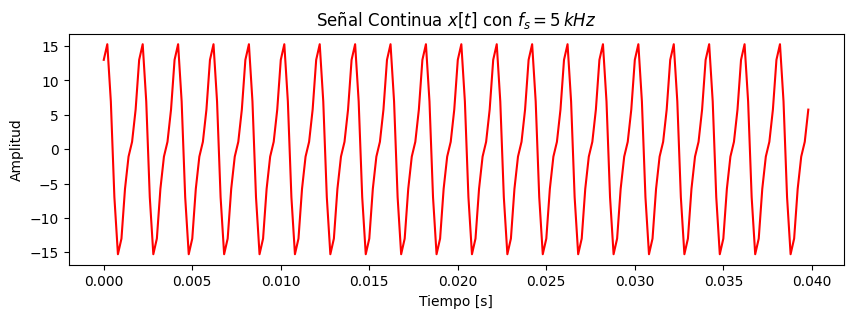

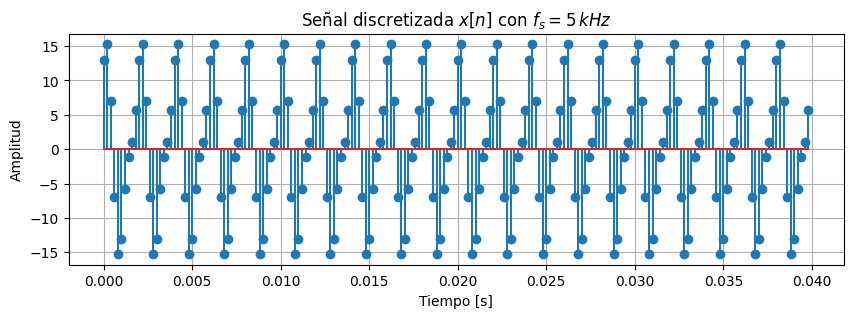

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

A = 3                    # Amplitud de ambas señales
B= 5
C= 10

T1 = 1 /500           # Periodo de la primera señal
T2 = 1/1000            # Periodo de la segunda señal
T3= 1/5500           # Periodo de la segunda señal
T = 1/50


w1 = 2 * np.pi / T1       # Frecuencia angular de la primera señal
w2 = 2 * np.pi / T2       # Frecuencia angular de la segunda señal
w3 = 2 * np.pi / T3       # Frecuencia angular de la tercera señal

Fs = 5000  # Frecuencia de muestreo (Hz)
Ts = 1 / Fs               # Periodo de muestreo
ti = 0
tf = 2*T

tv = np.arange(ti, tf, Ts)  # Vector de tiempo

# Señal compuesta
y = A * np.cos(w1 * tv) + B * np.sin(w2 * tv)+ C*np.cos(w3*tv)
y



plt.figure(figsize=(10, 3))
plt.title(r'Señal Continua $x[t]$ con $f_s = 5\,kHz$')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.plot(tv, y, c='r', label='ycs') # continua
plt.figure(figsize=(10, 3))
plt.stem(tv, y) # Discretiza
plt.title(r'Señal discretizada $x[n]$ con $f_s = 5\,kHz$')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid()
plt.show()




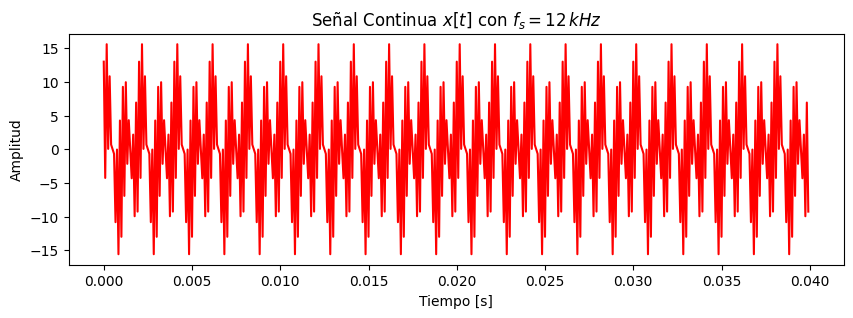

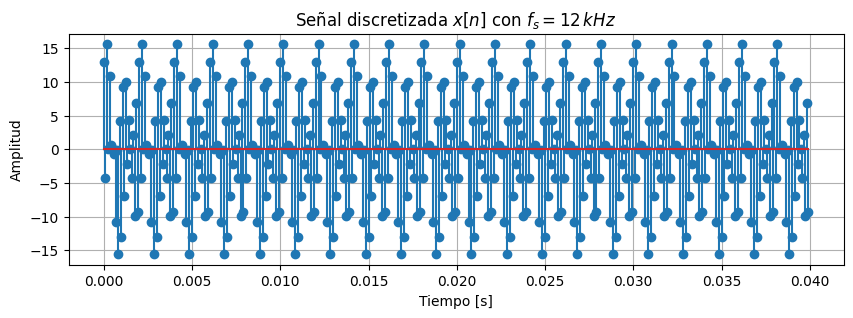

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

A = 3                    # Amplitud de ambas señales
B= 5
C= 10

T1 = 1 /500           # Periodo de la primera señal
T2 = 1/1000            # Periodo de la segunda señal
T3= 1/5500           # Periodo de la segunda señal
T = 1/50


w1 = 2 * np.pi / T1       # Frecuencia angular de la primera señal
w2 = 2 * np.pi / T2       # Frecuencia angular de la segunda señal
w3 = 2 * np.pi / T3       # Frecuencia angular de la tercera señal

Fs = 12000  # Frecuencia de muestreo (Hz)
Ts = 1 / Fs               # Periodo de muestreo
ti = 0
tf = 2*T

tv = np.arange(ti, tf, Ts)  # Vector de tiempo

# Señal compuesta
y = A * np.cos(w1 * tv) + B * np.sin(w2 * tv)+ C*np.cos(w3*tv)
y



plt.figure(figsize=(10, 3))
plt.title(r'Señal Continua $x[t]$ con $f_s = 12\,kHz$')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.plot(tv, y, c='r', label='ycs') # continua
plt.figure(figsize=(10, 3))
plt.stem(tv, y) # Discretiza
plt.title(r'Señal discretizada $x[n]$ con $f_s = 12\,kHz$')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid()
plt.show()




# EJERCICIO 3

 La distancia media entre dos senales x1(t), x2(t) ∈ R, C$$, se
puede expresar a partir de la potencia media
Sea la distancia como la potencia media:


$$
d(x_1, x_2) = P_{x_1 - x_2} = \lim_{T \to \infty} \frac{1}{T} \int_{T}^{} |x_1(t) - x_2(t)|^2 \, dt.
$$

Sean $$  x_1(t) , x_2(t) $$


$$
x_1(t) = A \cos(\omega_0 t), \quad \omega_0 = \frac{2\pi}{T}, \quad T, A \in \mathbb{R}^+
$$

$$
x_2(t) =
\begin{cases}
1 & \text{si } 0 \leq t < \frac{T}{4} \\
-1 & \text{si } \frac{T}{4} \leq t < \frac{3T}{4} \\
1 & \text{si } \frac{3T}{4} \leq t < T
\end{cases}
$$


¿Cuál es la distancia media entre las señales? Corrobore sus desarrollos con Sympy.



In [ ]:
import sympy as sp
import matplotlib.pyplot as plt


# Variables simbólicas
t, T, A = sp.symbols('t T A', real=True, positive=True)
w0 = 2 * sp.pi / T
x1 = A * sp.cos(w0 * t)

# el PIecewise es una Función por partes o a tramos
x2 = sp.Piecewise(
    (1, (t >= 0) & (t < T/4)),
    (-1, (t >= T/4) & (t < 3*T/4)),
    (1, (t >= 3*T/4) & (t < T))
)

# Expresión de la distancia media
ex = abs((x1 - x2))**2
d = (1/T) * sp.integrate(ex, (t, 0, T))

# Simplificar y mostrar el resultado
sp.simplify(d)







A**2/2 - 4*A/pi + 1

# EJERCICIO 4

$$
\textbf { Sea } x''(t) \text{ la segunda derivada de la señal } x(t), \text{ donde } t \in [t_i, t_f].
$$

$$
\text{Demuestre que los coeficientes de la serie exponencial de Fourier se pueden calcular según:}
$$

$$
c_n = \frac{1}{(t_i - t_f) n^2 \omega_0^2} \int_{t_i}^{t_f} x''(t) e^{-j n \omega_0 t} \, dt, \quad n \in \mathbb{Z}
$$

$$
\text{¿Cómo se pueden calcular los coeficientes } a_n \text{ y } b_n \text{ desde } x''(t) \text{ en la serie trigonométrica de Fourier?}
$$

$$
\text{Encuentre el espectro de Fourier, su magnitud, fase, parte real, parte imaginaria y el error relativo de reconstrucción}
$$

$$
\text{para } n \in \{0, \pm1, \pm2, \pm3, \pm4, \pm5\}, \text{ a partir de } x''(t) \text{ para la señal } x(t) \text{ en la Figura 1.}
$$

$$
\text{Compruebe el espectro obtenido con la estimación a partir de } x(t) \text{ y presente las respectivas simulaciones sobre Python.}
$$


$$
a_n = \frac{2}{T} \left\{ \frac{-A}{d_2 - d_1} \left[ \frac{(d_2 - d_1) (-\sin(n\omega_0 d_1))}{n\omega_0} + \frac{\cos(n\omega_0 d_1) - \cos(n\omega_0 d_2)}{(n\omega_0)^2} \right] - \frac{2A \sin(n\omega_0 d_1)}{n\omega_0} + \frac{A}{d_2 - d_1} \left[ \frac{\cos(n\omega_0 d_2) - \cos(n\omega_0 d_1)}{(n\omega_0)^2} - \frac{(d_1 - d_2) \sin(n\omega_0 d_1)}{n\omega_0} \right] \right\}
$$

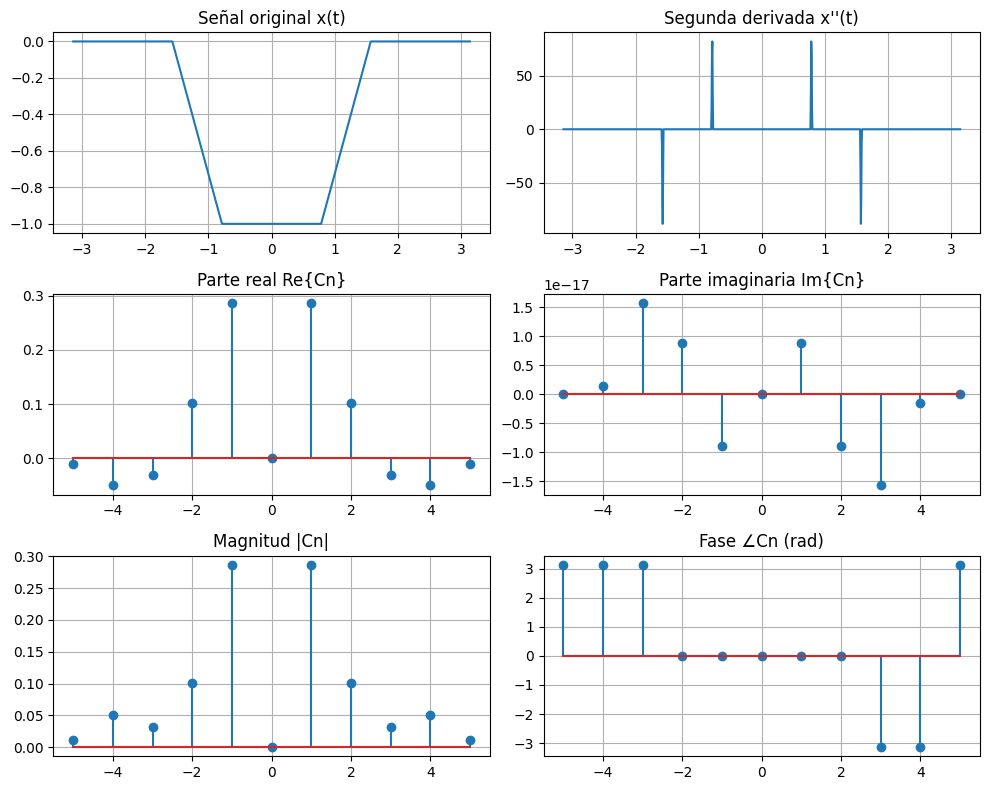

Error relativo de reconstrucción: 1.6524e+00


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid  # Mejor que np.trapz

# Parámetros de la señal
T = 2*np.pi        # Periodo
w0 = 2*np.pi/T     # Frecuencia fundamental
A = 1              # Altura (recuerda que el valor real de A puede cambiar)
d1 = T/8
d2 = T/4
N = 5              # Número de armónicos positivos y negativos

# Malla temporal
t = np.linspace(-T/2, T/2, 1000)
x = np.zeros_like(t)

# Pendientes
m1 = -A / (d2 - d1)
m2 = -m1

# Definición por tramos de x(t)
x += np.where((t >= -d2) & (t < -d1), m1 * (t + d2), 0)
x += np.where((t >= -d1) & (t < d1), -A, 0)
x += np.where((t >= d1) & (t < d2), m2 * (t - d2), 0)

# Segunda derivada de x(t)
dt = t[1] - t[0]
x2 = np.gradient(np.gradient(x, dt), dt)

# Cálculo de coeficientes c_n desde x''(t)
cn = np.zeros(2*N+1, dtype=complex)
nv = np.arange(-N, N+1)

for i, n in enumerate(nv):
    if n == 0:
        cn[i] = 0
    else:
        exponencial = np.exp(-1j * n * w0 * t)
        integral = trapezoid(x2 * exponencial, t)
        cn[i] = integral / (T * (n**2) * w0**2)

# Reconstrucción de x(t) a partir de c_n
x_rec = np.zeros_like(t, dtype=complex)
for i, n in enumerate(nv):
    x_rec += cn[i] * np.exp(1j * n * w0 * t)

# Error relativo de reconstrucción
error = np.linalg.norm(x - x_rec.real) / np.linalg.norm(x)

# Gráficas
fig = plt.figure(figsize=(10, 8))

plt.subplot(3,2,1)
plt.plot(t, x)
plt.title("Señal original x(t)")
plt.grid()

plt.subplot(3,2,2)
plt.plot(t, x2)
plt.title("Segunda derivada x''(t)")
plt.grid()

plt.subplot(3,2,3)
plt.stem(nv, np.real(cn))
plt.title("Parte real Re{Cn}")
plt.grid()

plt.subplot(3,2,4)
plt.stem(nv, np.imag(cn))
plt.title("Parte imaginaria Im{Cn}")
plt.grid()

plt.subplot(3,2,5)
plt.stem(nv, np.abs(cn))
plt.title("Magnitud |Cn|")
plt.grid()

plt.subplot(3,2,6)
plt.stem(nv, np.angle(cn))
plt.title("Fase ∠Cn (rad)")
plt.grid()

fig.tight_layout()
plt.show()

# Mostrar error
print(f"Error relativo de reconstrucción: {error:.4e}")
